In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("tshirt.csv")
df.head()

,Height,Wight,Size
0,158,58,M
1,158,59,M
2,158,63,M
3,160,59,M
4,160,60,M


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Height  18 non-null     int64 
 1   Wight   18 non-null     int64 
 2   Size    18 non-null     object
dtypes: int64(2), object(1)
memory usage: 564.0+ bytes


In [5]:
df['Weight']=df['Wight']

In [6]:
df.drop('Wight',axis=1,inplace=True)

In [7]:
df.head()

,Height,Size,Weight
0,158,M,58
1,158,M,59
2,158,M,63
3,160,M,59
4,160,M,60


In [8]:
x=df[["Weight","Height"]]
y=df['Size']
print(x.shape)
print(y.shape)

(18, 2)
(18,)


In [9]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x,y)
prediction=model.predict(x)
print(prediction)

['M' 'M' 'M' 'M' 'M' 'M' 'L' 'M' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L' 'L']


In [10]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[10  1]
 [ 1  6]]


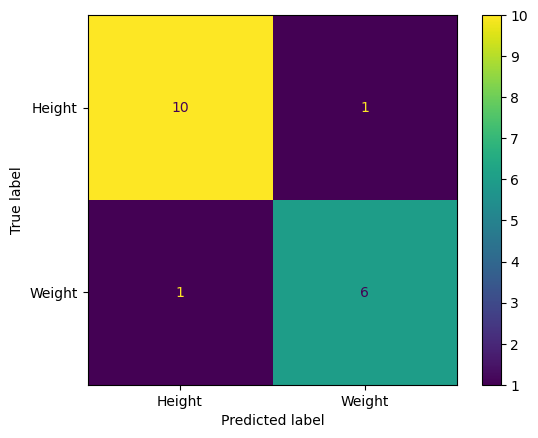

In [11]:
import matplotlib.pyplot as plt

from sklearn import metrics
cm_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Height','Weight'])
cm_disp.plot()
plt.show()

In [12]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

10 1 1 6


In [13]:
from sklearn.metrics import accuracy_score
print("Accuracy Score = ",accuracy_score(y,prediction))

Accuracy Score =  0.8888888888888888


In [14]:
error_rate=1-((TP+TN)/(TP+TN+FP+FN))
print("Error Rate = ",error_rate)

Error Rate =  0.11111111111111116


In [15]:
df=pd.read_csv("AptitudeCommunication.csv")
df.head()

,Name,Aptitude,Communication,Class
0,Karuna,2,5.0,Speaker
1,Bhavan,2,6.0,Speaker
2,Gaurav,7,6.0,Leader
3,Parul,7,2.5,Intel
4,Dinesh,8,6.0,Leader


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Name           14 non-null     object 
 1   Aptitude       14 non-null     int64  
 2   Communication  14 non-null     float64
 3   Class          14 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 580.0+ bytes


In [17]:
df.drop("Name",axis=1,inplace=True)

In [18]:
df.head()

,Aptitude,Communication,Class
0,2,5.0,Speaker
1,2,6.0,Speaker
2,7,6.0,Leader
3,7,2.5,Intel
4,8,6.0,Leader


In [19]:
x=df[["Aptitude","Communication"]]
y=df["Class"]
print(x.shape)
print(y.shape)

(14, 2)
(14,)


In [20]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=5)
model.fit(x,y)
prediction=model.predict(x)
print(prediction)

['Speaker' 'Speaker' 'Leader' 'Intel' 'Leader' 'Speaker' 'Intel' 'Speaker'
 'Intel' 'Leader' 'Intel' 'Leader' 'Intel' 'Leader']


In [21]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[5 0 0]
 [0 5 0]
 [0 0 4]]


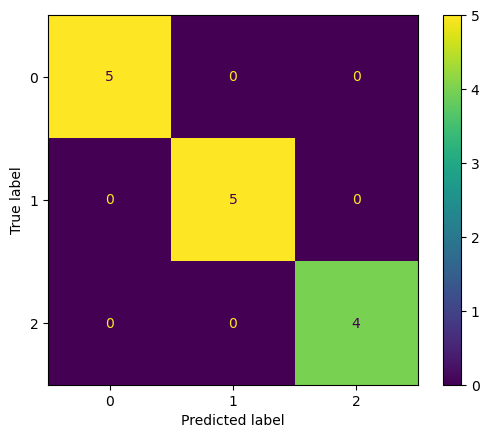

In [22]:
import matplotlib.pyplot as plt

from sklearn import metrics
cm_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['0','1','2'])
cm_disp.plot()
plt.show()

In [23]:
from sklearn.metrics import accuracy_score
print("Accuracy Score = ",accuracy_score(y,prediction))

Accuracy Score =  1.0


# Decision Tree :

- root node
- decison node
- leaf/terminal node

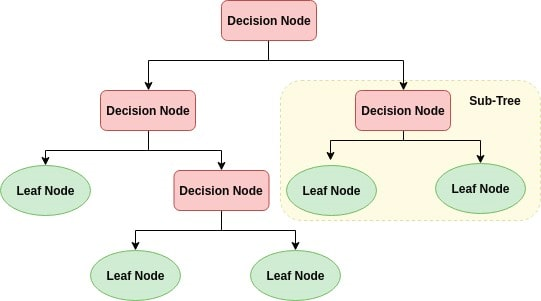

In [24]:
df=pd.read_csv("DecisionTreeDataset -Num.csv")
df.head()

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1


In [25]:
y=df["Job Offered"]
x=df[['CGPA','Communication','Apptitude','Programming Skill']]

In [26]:
from sklearn.tree import DecisionTreeClassifier
dtree_entropy=DecisionTreeClassifier(criterion="entropy")
model=dtree_entropy.fit(x,y)
pred=dtree_entropy.predict(x)
pred

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1])

In [27]:
diff=pd.DataFrame({"Actual":y,"Predicted":pred})

In [28]:
diff

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,1,1
9,1,1


In [30]:
df=pd.read_csv('DecisionTree_Sports.csv')
df.head()

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes


In [35]:
import numpy as np

df['Weather'] = np.where(df['Weather'] == 'Cloudy',0,
                        np.where(df['Weather'] == 'Rain',1,2))

In [36]:
df['Temperature'] = np.where(df['Temperature']=='Cool',0,
                            np.where(df['Temperature']=='Hot',1,2))


In [37]:
df['Humidity']=np.where(df['Humidity']=='High',0,1)
df['Wind']=np.where(df['Wind']=="Strong",0,1)
df['Play_Sports?']=np.where(df['Play_Sports?']=="No",0,1)

In [38]:
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,1,0
1,Day 2,2,1,0,0,0
2,Day 3,0,1,0,1,1
3,Day 4,1,2,0,1,1
4,Day 5,1,0,1,1,1
5,Day 6,1,0,1,0,0
6,Day 7,0,0,1,0,1
7,Day 8,2,2,0,1,0
8,Day 9,2,0,1,1,1
9,Day 10,1,2,1,1,1


In [42]:
df.drop('Day',axis=1,inplace=True)

In [43]:
df.head()

,Weather,Temperature,Humidity,Wind,Play_Sports?
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1


In [44]:
x=df.iloc[:,:4]
y=df.iloc[:,-1]
print(x.shape)
print(y.shape)

(14, 4)
(14,)


In [45]:
x.columns

Index(['Weather', 'Temperature', 'Humidity', 'Wind'], dtype='object')

In [46]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy')
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [48]:
from sklearn.tree import export_text
text_representation=export_text(dtree)
print(text_representation)

|--- feature_0 <= 0.50
|   |--- class: 1
|--- feature_0 >  0.50
|   |--- feature_2 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- feature_3 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_3 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 0
|   |--- feature_2 >  0.50
|   |   |--- feature_3 <= 0.50
|   |   |   |--- feature_0 <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  1.50
|   |   |   |   |--- class: 1
|   |   |--- feature_3 >  0.50
|   |   |   |--- class: 1



In [50]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix

cm=confusion_matrix(y,prediction)
print("confusion_matrix = ",cm)

confusion_matrix =  [[5 0]
 [0 9]]


In [51]:
accuracy_score(y,prediction)

1.0

In [52]:
recall_score(y,prediction)

1.0

In [53]:
precision_score(y,prediction)

1.0

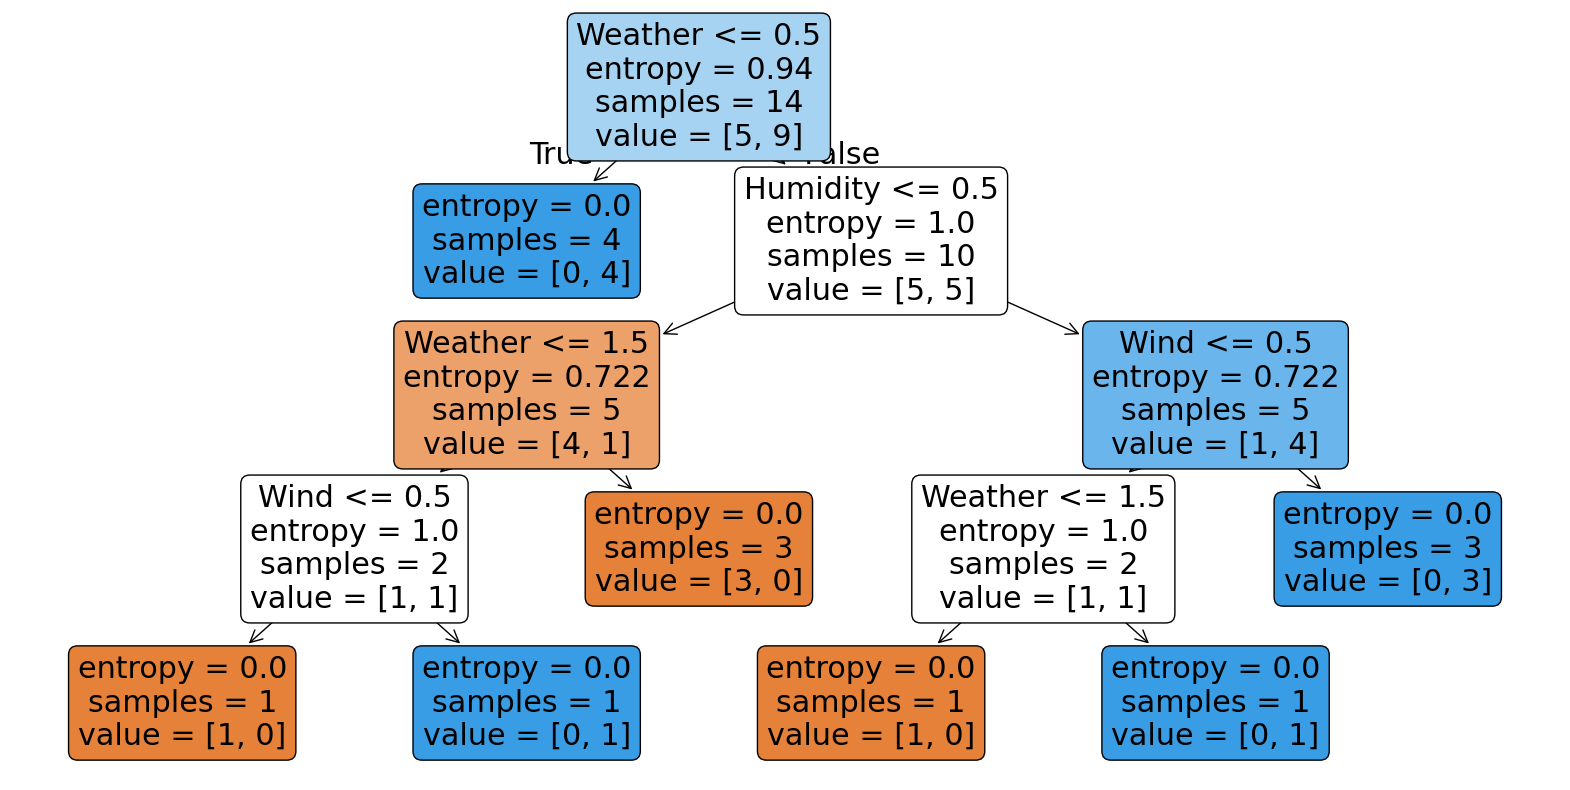

In [55]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtree,feature_names=x.columns,filled=True,rounded=True)
plt.show()

In [60]:
df=pd.read_csv('DecisionTreeDataset -Num.csv')
df.head()

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1


In [61]:
y=df["Job Offered"]
x=df[['CGPA','Communication','Apptitude','Programming Skill']]

In [71]:
from sklearn.tree import DecisionTreeClassifier
dtree_entropy=DecisionTreeClassifier(criterion="entropy",max_depth= 3)
model=dtree_entropy.fit(x,y)
pred=dtree_entropy.predict(x)
pred

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1])

In [72]:
from sklearn.tree import export_text
text_representation=export_text(dtree)
print(text_representation)

|--- feature_0 <= 0.50
|   |--- class: 1
|--- feature_0 >  0.50
|   |--- feature_2 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- feature_3 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_3 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 0
|   |--- feature_2 >  0.50
|   |   |--- feature_3 <= 0.50
|   |   |   |--- feature_0 <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  1.50
|   |   |   |   |--- class: 1
|   |   |--- feature_3 >  0.50
|   |   |   |--- class: 1



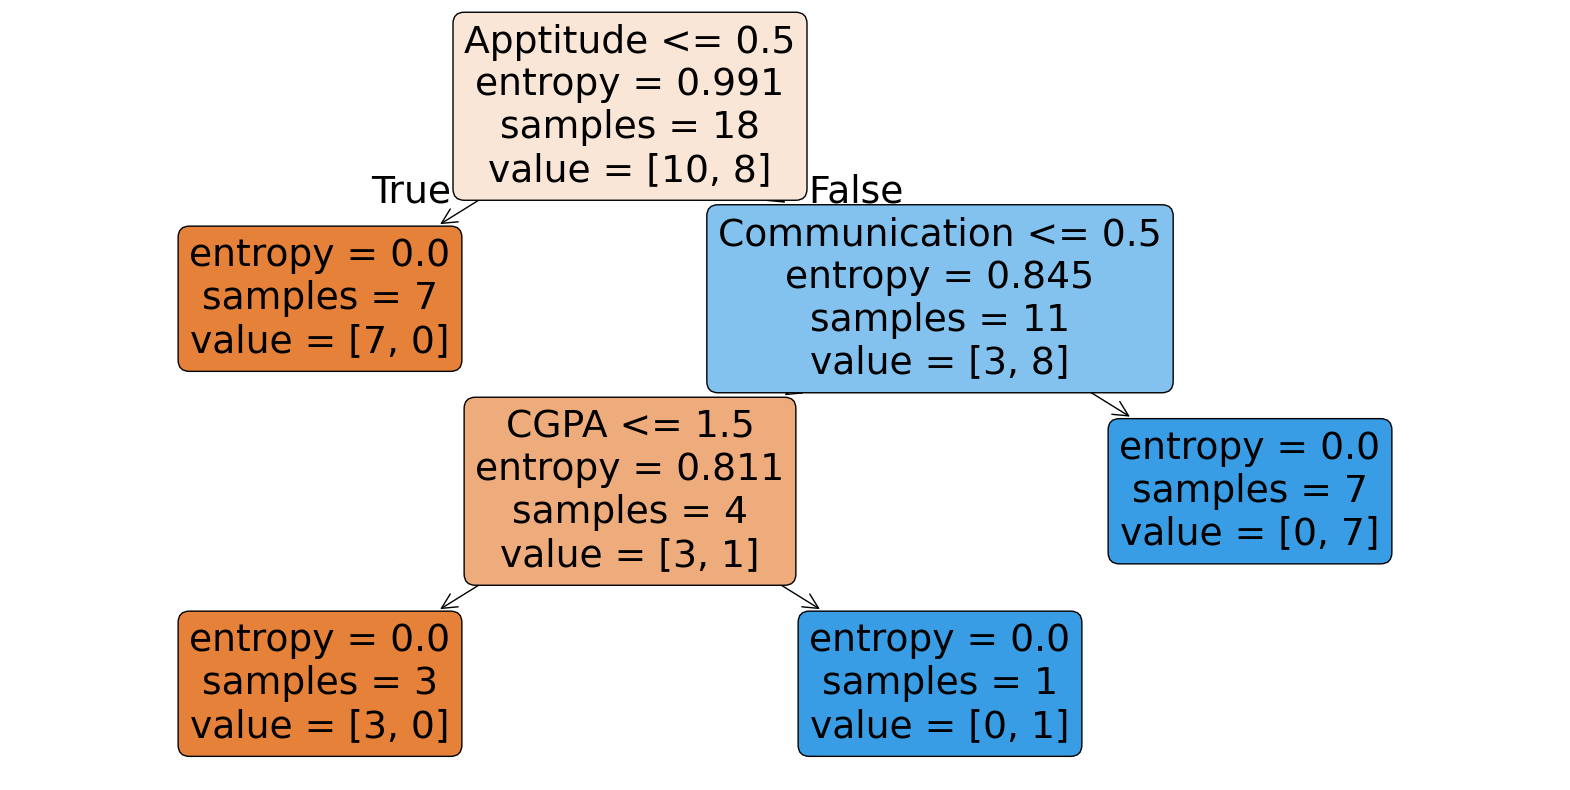

In [73]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtree_entropy,feature_names=x.columns,filled=True,rounded=True)
plt.show()

In [74]:
dtree_entropy.get_depth()

3

In [76]:
df=pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [77]:
x=df.iloc[:,0:8]
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [78]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [79]:
from sklearn.tree import DecisionTreeClassifier
dtree_entropy=DecisionTreeClassifier(criterion="entropy",max_depth= 3)
model=dtree_entropy.fit(x_train,y_train)
pred=dtree_entropy.predict(x_test)
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [80]:
from sklearn.tree import export_text
text_representation=export_text(dtree)
print(text_representation)

|--- feature_0 <= 0.50
|   |--- class: 1
|--- feature_0 >  0.50
|   |--- feature_2 <= 0.50
|   |   |--- feature_0 <= 1.50
|   |   |   |--- feature_3 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_3 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_0 >  1.50
|   |   |   |--- class: 0
|   |--- feature_2 >  0.50
|   |   |--- feature_3 <= 0.50
|   |   |   |--- feature_0 <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- feature_0 >  1.50
|   |   |   |   |--- class: 1
|   |   |--- feature_3 >  0.50
|   |   |   |--- class: 1



In [83]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score
cm=confusion_matrix(y_test,pred)
print(cm)

[[88 11]
 [20 35]]


In [86]:
print("Accuracy score = ",accuracy_score(y_test,pred))

Accuracy score =  0.7987012987012987


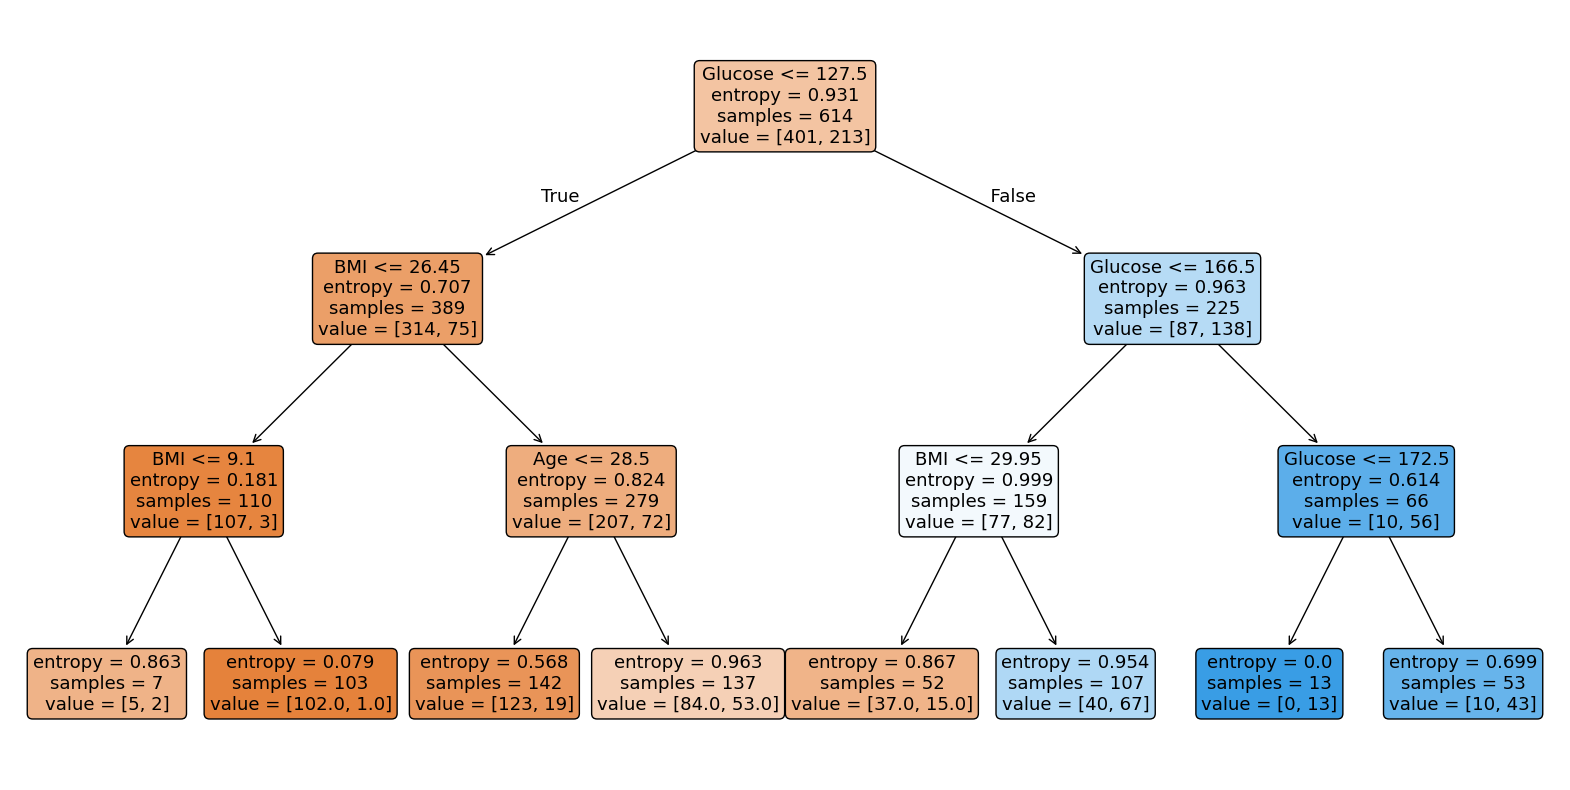

In [87]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dtree_entropy,feature_names=x.columns,filled=True,rounded=True)
plt.show()

# Random Forest

***1. Baging (Bootstrap Aggregating) :*** Take original dataset and creates "random samples with replacement"

***2. Feature Randomness***

In [99]:
df=pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [101]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [102]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [103]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [104]:
df['Sex']=np.where(df['Sex']=='male',1,0)

In [105]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [108]:
x=df[['Pclass','Sex','Age','SibSp','Parch','Fare']]
y=df['Survived']

In [109]:
print(x.shape)
print(y.shape)

(891, 6)
(891,)


In [110]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


In [112]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(criterion='entropy',n_estimators=100,random_state=42)

rf_classifier.fit(x_train,y_train)
pred=rf_classifier.predict(x_test)
print(pred)

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1]


In [115]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix

cm=confusion_matrix(y_test,pred)
print("confusion_matrix = ",cm)

confusion_matrix =  [[95 11]
 [31 42]]


In [116]:
print("Accuracy = ",accuracy_score(y_test,pred))

Accuracy =  0.7653631284916201


In [117]:
print("Recall score  = ",recall_score(y_test,pred))

Recall score  =  0.5753424657534246


In [118]:
print("Precision score = ",precision_score(y_test,pred))

Precision score =  0.7924528301886793


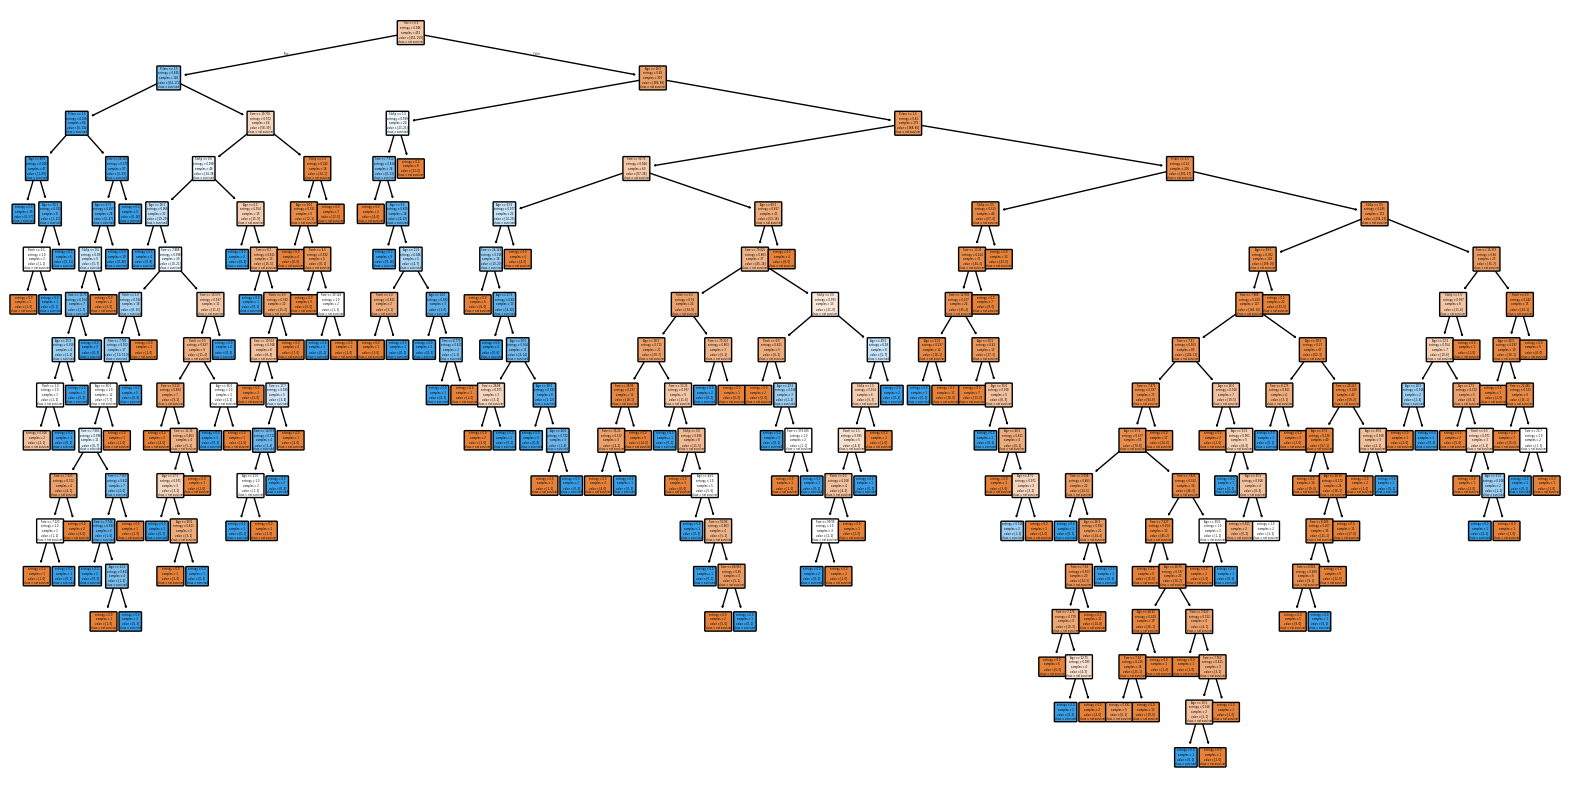

In [120]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
choose_tree=rf_classifier.estimators_[0]
plot_tree(choose_tree,feature_names=x.columns,class_names=["not surviver",'survived'],filled=True,rounded=True)
plt.show()
